# Função Quadrática: Gráfico e Propriedades

**Módulo:** 01 – Conjuntos e Funções

**Pré-requisitos:** [`0107a_funcoes_primeiro_grau.ipynb`](0107a_funcoes_primeiro_grau.ipynb) (função afim, coeficiente angular/linear, zero de uma função) e [`0105a_funcoes.ipynb`](0105a_funcoes.ipynb) (conceito de função, domínio/contradomínio/imagem, gráfico no plano cartesiano), além do Python básico de [00_fundamentos_e_python/](../00_fundamentos_e_python/) (`def`, `matplotlib` simples) e resolução de equações do 1º grau

**Objetivos de aprendizagem:**
- Reconhecer e escrever uma função quadrática em suas diferentes formas (geral, fatorada, canônica).
- Esboçar o gráfico de uma parábola e identificar sua concavidade.
- Calcular zeros, vértice, eixo de simetria e imagem de uma função quadrática.
- Aplicar função quadrática em problemas de otimização e de queda livre / MUV.

**Tempo estimado:** 90 a 120 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/01_conjuntos_e_funcoes/0108a_funcao_quadratica_grafico_e_propriedades.ipynb)

## A cerca de 40 metros

Você tem **40 metros** de cerca e um terreno junto a um muro reto — como o muro já fecha um dos lados, só é preciso cercar os outros **três lados** de uma área retangular.

Você pode fazer um retângulo bem comprido e estreito, ou bem curto e largo, ou algo no meio-termo — os 40 metros de cerca sempre dão para fechar *algum* retângulo. A pergunta é:

> **Qual é o formato que cerca a maior área possível?**

Repare que existe um "meio-termo" ótimo: um retângulo longo e fino tem pouca área (é quase uma linha), um retângulo curto e largo também tem pouca área (sobra pouca profundidade) — em algum ponto entre os dois extremos, a área é máxima. Ainda não sabemos calcular esse ponto, mas vamos guardar essa pergunta: ao longo deste notebook vamos construir exatamente a ferramenta matemática que resolve esse tipo de "sobe e desce" — a **função quadrática** — e no final voltamos para fechar a cerca do jeito ótimo.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp
import ipywidgets as widgets
from IPython.display import display

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


def funcao_quadratica(x, a: float, b: float, c: float):
    """Calcula f(x) = a*x^2 + b*x + c."""
    return a * x**2 + b * x + c


x_sym = sp.symbols("x")

## Função quadrática: definição geral

- 📌 **Definição formal:** uma função f: R → R é chamada de **função quadrática** (ou função polinomial do 2º grau) quando pode ser escrita na forma **f(x) = ax² + bx + c**, com a, b, c ∈ R e **a ≠ 0**.
- A condição a ≠ 0 é obrigatória: se a = 0, o termo x² desaparece e f(x) = bx + c vira uma **função afim** (ou constante, se b = 0 também) — perde exatamente o termo que dá o nome e a forma característica à função quadrática.
- a, b e c são chamados de **coeficientes** da função quadrática — o papel de cada um vai ficar claro ao longo do notebook.

**Exemplos de funções quadráticas:**
- f(x) = x² - 5x + 6 (a = 1, b = -5, c = 6 — todos os termos presentes)
- f(x) = 2x² - 8 (a = 2, b = 0, c = -8 — sem termo em x)
- f(x) = -x² + 4x (a = -1, b = 4, c = 0 — sem termo constante)
- f(x) = 3x² (a = 3, b = 0, c = 0 — só o termo quadrático)

**Contraexemplos (não são quadráticas):**
- f(x) = 3x + 5 — é afim, não tem termo em x² (a = 0 não é permitido)
- f(x) = x³ - x — é do 3º grau, não do 2º

**Perguntas de checagem:**
1. Por que a condição a ≠ 0 é obrigatória na definição de função quadrática?
2. f(x) = 5 (função constante) pode ser vista como um caso particular de função quadrática? Por quê?

## Gráfico e parábola

💡 Toda função quadrática tem como gráfico uma curva chamada **parábola**. A demonstração formal disso não é o foco aqui — o foco é reconhecer visualmente essa forma característica em "U" (ou "∩").

O gráfico abaixo mostra três parábolas que só diferem no coeficiente a, todas com b = 0 e c = 0 — ou seja, comparando f(x) = ax² para três valores de a.

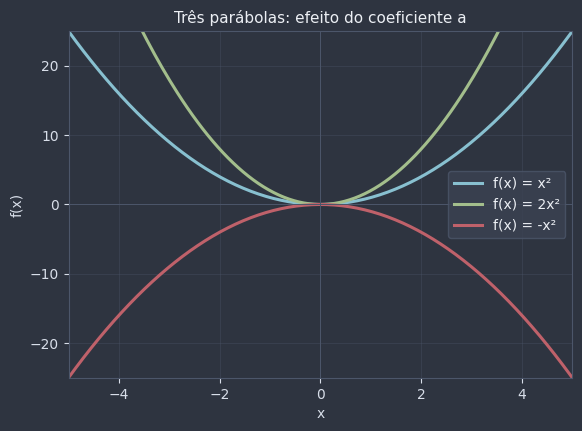

In [2]:
xs_comparacao = np.linspace(-5, 5, 200)

parabolas_comparacao = [
    ("f(x) = x²", funcao_quadratica(xs_comparacao, 1, 0, 0), COR_PONTO),
    ("f(x) = 2x²", funcao_quadratica(xs_comparacao, 2, 0, 0), COR_DESTAQUE),
    ("f(x) = -x²", funcao_quadratica(xs_comparacao, -1, 0, 0), COR_ALERTA),
]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
for nome, ys, cor in parabolas_comparacao:
    ax.plot(xs_comparacao, ys, color=cor, linewidth=2.2, label=nome)
ax.axhline(0, color=NORD_LINHA, linewidth=0.7)
ax.axvline(0, color=NORD_LINHA, linewidth=0.7)
ax.set_xlim(-5, 5)
ax.set_ylim(-25, 25)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA)
ax.set_xlabel("x", color=NORD_TEXTO_SEC)
ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
ax.set_title("Três parábolas: efeito do coeficiente a", color=NORD_TEXTO, fontsize=11)
plt.show()

🕹️ **Widget interativo:** mexa no slider de a e observe f(x) = ax² mudando em tempo real — repare como a parábola fica mais "fechada" (mais estreita) quando |a| aumenta, e mais "aberta" (mais achatada) quando |a| se aproxima de 0.

In [3]:
def explorar_coeficiente_a(a: float) -> None:
    if a == 0:
        print("a = 0 -> deixa de ser função quadrática (o termo x² desaparece)")
        return

    xs = np.linspace(-5, 5, 200)
    ys = funcao_quadratica(xs, a, 0, 0)

    fig, ax = plt.subplots(figsize=(6.5, 4.3))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(xs, ys, color=COR_DESTAQUE, linewidth=2.4)
    ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-25, 25)
    ax.set_xlabel("x", color=NORD_TEXTO_SEC)
    ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
    ax.set_title(f"f(x) = {a:g}x²", color=NORD_TEXTO, fontsize=11)
    plt.show()

    tabela = pd.DataFrame({"x": np.array([-2.0, -1.0, 0.0, 1.0, 2.0])})
    tabela["f(x)"] = funcao_quadratica(tabela["x"], a, 0, 0)
    display(tabela)


widgets.interact(
    explorar_coeficiente_a,
    a=widgets.FloatSlider(value=1.0, min=-3, max=3, step=0.5, description="a:"),
)

interactive(children=(FloatSlider(value=1.0, description='a:', max=3.0, min=-3.0, step=0.5), Output()), _dom_c…

<function __main__.explorar_coeficiente_a(a: float) -> None>

**Perguntas de checagem:**
1. O que muda visualmente quando o coeficiente a aumenta em módulo (a parábola fica mais "fechada" ou mais "aberta")?
2. Duas parábolas têm a = 2 e a = -2. Elas têm a mesma "largura"? O que muda entre elas?

## Concavidade

📌 A **concavidade** da parábola é determinada pelo sinal de a:

- **a > 0** → concavidade para cima (formato de "U")
- **a < 0** → concavidade para baixo (formato de "∩")

O gráfico abaixo isola esse efeito: duas parábolas com o mesmo \|a\|, b e c, diferindo só no sinal de a.

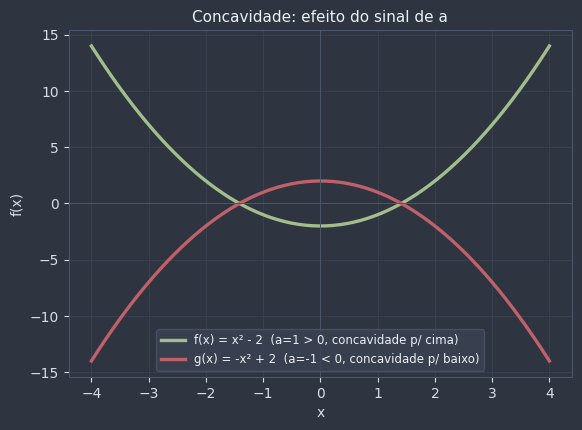

In [4]:
xs_concav = np.linspace(-4, 4, 200)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(
    xs_concav, funcao_quadratica(xs_concav, 1, 0, -2), color=COR_DESTAQUE,
    linewidth=2.4, label="f(x) = x² - 2  (a=1 > 0, concavidade p/ cima)",
)
ax.plot(
    xs_concav, funcao_quadratica(xs_concav, -1, 0, 2), color=COR_ALERTA,
    linewidth=2.4, label="g(x) = -x² + 2  (a=-1 < 0, concavidade p/ baixo)",
)
ax.axhline(0, color=NORD_LINHA, linewidth=0.7)
ax.axvline(0, color=NORD_LINHA, linewidth=0.7)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=8.5)
ax.set_xlabel("x", color=NORD_TEXTO_SEC)
ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
ax.set_title("Concavidade: efeito do sinal de a", color=NORD_TEXTO, fontsize=11)
plt.show()

🕹️ **Widget interativo:** o mesmo slider de a de antes, agora anotando dinamicamente a concavidade no título do gráfico.

In [5]:
def explorar_concavidade(a: float) -> None:
    if a == 0:
        print("a = 0 -> deixa de ser função quadrática (o termo x² desaparece)")
        return

    concavidade = "para cima (U)" if a > 0 else "para baixo (∩)"
    xs = np.linspace(-5, 5, 200)
    ys = funcao_quadratica(xs, a, 0, 0)

    fig, ax = plt.subplots(figsize=(6.5, 4.3))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    cor_curva = COR_DESTAQUE if a > 0 else COR_ALERTA
    ax.plot(xs, ys, color=cor_curva, linewidth=2.4)
    ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-25, 25)
    ax.set_xlabel("x", color=NORD_TEXTO_SEC)
    ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
    ax.set_title(f"f(x) = {a:g}x²  ->  concavidade {concavidade}", color=NORD_TEXTO, fontsize=11)
    plt.show()

    print(f"a = {a:g}  ->  concavidade {concavidade}")


widgets.interact(
    explorar_concavidade,
    a=widgets.FloatSlider(value=1.0, min=-3, max=3, step=0.5, description="a:"),
)

interactive(children=(FloatSlider(value=1.0, description='a:', max=3.0, min=-3.0, step=0.5), Output()), _dom_c…

<function __main__.explorar_concavidade(a: float) -> None>

**Perguntas de checagem:**
1. Se a < 0, o que isso indica sobre a existência de um valor máximo da função?
2. É possível uma parábola ter concavidade para cima em uma parte do gráfico e para baixo em outra?

## Zeros da função (discriminante, Bhaskara e forma fatorada)

📌 Os **zeros** (ou raízes) de f são os valores de x para os quais f(x) = 0. Para encontrá-los, introduzimos o **discriminante**:

$$\Delta = b^2 - 4ac$$

e a **fórmula de Bhaskara**:

$$x = \frac{-b \pm \sqrt{\Delta}}{2a}$$

O sinal de Δ decide quantas raízes reais existem:

- **Δ > 0** → duas raízes reais distintas (a parábola cruza o eixo x em dois pontos)
- **Δ = 0** → uma raiz real "dupla" (a parábola toca o eixo x em um único ponto)
- **Δ < 0** → nenhuma raiz real (a parábola nunca toca o eixo x)

Quando existem raízes reais x₁ e x₂, a função também pode ser escrita na **forma fatorada**:

$$f(x) = a(x - x_1)(x - x_2)$$

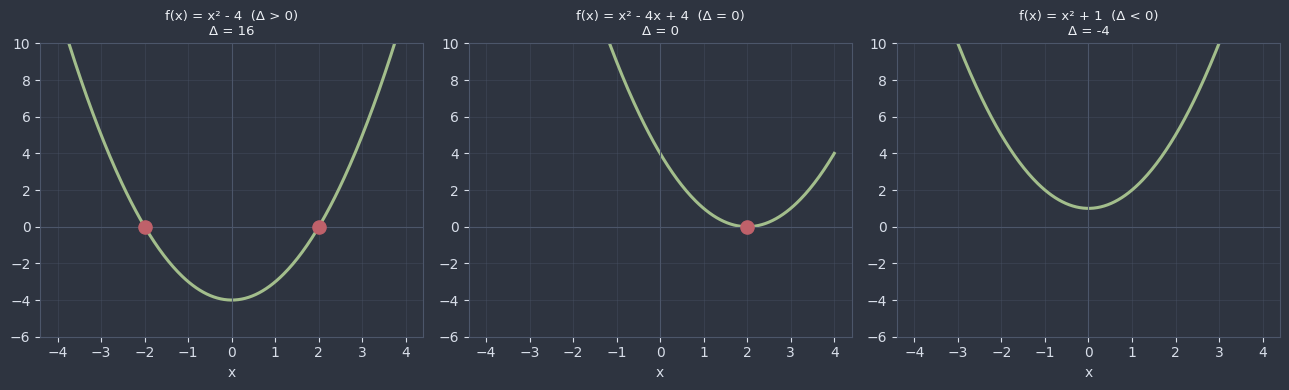

In [7]:
casos_delta = [
    ("f(x) = x² - 4  (Δ > 0)", 1, 0, -4),
    ("f(x) = x² - 4x + 4  (Δ = 0)", 1, -4, 4),
    ("f(x) = x² + 1  (Δ < 0)", 1, 0, 1),
]

fig, eixos = plt.subplots(1, 3, figsize=(13, 4))
fig.patch.set_facecolor(NORD_FUNDO)
xs_delta = np.linspace(-4, 4, 300)

for eixo, (titulo, a_c, b_c, c_c) in zip(eixos, casos_delta):
    estilizar_eixo(eixo)
    ys = funcao_quadratica(xs_delta, a_c, b_c, c_c)
    eixo.plot(xs_delta, ys, color=COR_DESTAQUE, linewidth=2.2)
    eixo.axhline(0, color=NORD_LINHA, linewidth=0.8)
    eixo.axvline(0, color=NORD_LINHA, linewidth=0.8)

    delta_c = b_c**2 - 4 * a_c * c_c
    if delta_c > 0:
        raiz1 = (-b_c - np.sqrt(delta_c)) / (2 * a_c)
        raiz2 = (-b_c + np.sqrt(delta_c)) / (2 * a_c)
        eixo.scatter([raiz1, raiz2], [0, 0], s=90, color=COR_ALERTA, zorder=3)
    elif delta_c == 0:
        raiz = -b_c / (2 * a_c)
        eixo.scatter([raiz], [0], s=90, color=COR_ALERTA, zorder=3)

    eixo.set_ylim(-6, 10)
    eixo.set_title(f"{titulo}\nΔ = {delta_c:g}", color=NORD_TEXTO, fontsize=9.5)
    eixo.set_xlabel("x", color=NORD_TEXTO_SEC)

plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** sliders para a, b e c, recalculando Δ e mostrando quantas raízes reais existem.

In [ ]:
def explorar_zeros(a: float, b: float, c: float) -> None:
    if a == 0:
        print("a = 0 -> não é função quadrática")
        return

    delta = b**2 - 4 * a * c
    xs = np.linspace(-10, 10, 400)
    ys = funcao_quadratica(xs, a, b, c)

    fig, ax = plt.subplots(figsize=(6.5, 4.3))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(xs, ys, color=COR_DESTAQUE, linewidth=2.2)
    ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.8)

    if delta > 0:
        raiz1 = (-b - np.sqrt(delta)) / (2 * a)
        raiz2 = (-b + np.sqrt(delta)) / (2 * a)
        ax.scatter([raiz1, raiz2], [0, 0], s=90, color=COR_ALERTA, zorder=3)
        mensagem = f"Δ = {delta:g} > 0  ->  duas raízes reais: x1 = {raiz1:.2f}, x2 = {raiz2:.2f}"
    elif delta == 0:
        raiz = -b / (2 * a)
        ax.scatter([raiz], [0], s=90, color=COR_ALERTA, zorder=3)
        mensagem = f"Δ = {delta:g} = 0  ->  uma raiz real (dupla): x = {raiz:.2f}"
    else:
        mensagem = f"Δ = {delta:g} < 0  ->  nenhuma raiz real (a parábola não cruza o eixo x)"

    y_min = min(ys.min(), -1)
    y_max = max(ys.max(), 1)
    ax.set_ylim(y_min - 1, y_max + 1)
    ax.set_xlabel("x", color=NORD_TEXTO_SEC)
    ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
    ax.set_title(f"f(x) = {a:g}x² + {b:g}x + {c:g}", color=NORD_TEXTO, fontsize=11)
    plt.show()
    print(mensagem)


widgets.interact(
    explorar_zeros,
    a=widgets.FloatSlider(value=1.0, min=-3, max=3, step=0.5, description="a:"),
    b=widgets.FloatSlider(value=0.0, min=-10, max=10, step=1, description="b:"),
    c=widgets.FloatSlider(value=-4.0, min=-10, max=10, step=1, description="c:"),
)

interactive(children=(FloatSlider(value=1.0, description='a:', max=3.0, min=-3.0, step=0.5), FloatSlider(value…

<function __main__.explorar_zeros(a: float, b: float, c: float) -> None>

**Perguntas de checagem:**
1. O que significa, graficamente, a parábola ter Δ < 0?
2. Toda função quadrática pode ser escrita na forma fatorada? Por quê? (pense em quando Δ < 0)

## Forma canônica e translações

📌 Completando o quadrado em f(x) = ax² + bx + c, chegamos à **forma canônica**:

$$f(x) = a(x - h)^2 + k, \qquad h = -\frac{b}{2a}, \quad k = f(h)$$

**Exemplo passo a passo:** f(x) = x² - 6x + 5

1. Colocar em evidência o termo entre parênteses: f(x) = (x² - 6x) + 5
2. Completar o quadrado: x² - 6x = (x - 3)² - 9
3. Substituir de volta: f(x) = (x - 3)² - 9 + 5 = (x - 3)² - 4

Ou seja, h = 3 e k = -4 — confira abaixo com sympy.

In [9]:
a_exemplo, b_exemplo, c_exemplo = 1, -6, 5
h_exemplo = sp.Rational(-b_exemplo, 2 * a_exemplo)
k_exemplo = a_exemplo * h_exemplo**2 + b_exemplo * h_exemplo + c_exemplo

x_forma = sp.symbols("x")
forma_canonica_sym = a_exemplo * (x_forma - h_exemplo) ** 2 + k_exemplo
print(f"f(x) = x² - 6x + 5  ->  forma canônica: f(x) = {sp.expand(forma_canonica_sym)}")
print(f"h = {h_exemplo}, k = {k_exemplo}")
print(f"conferindo (expandir a forma canônica): {sp.expand(forma_canonica_sym)}")

f(x) = x² - 6x + 5  ->  forma canônica: f(x) = x**2 - 6*x + 5
h = 3, k = -4
conferindo (expandir a forma canônica): x**2 - 6*x + 5


💡 h e k representam **translações** do gráfico de f(x) = ax²: h desloca a parábola horizontalmente e k a desloca verticalmente. O gráfico abaixo compara f(x) = x² (referência, cor neutra) com a versão deslocada f(x) = (x-3)² - 4.

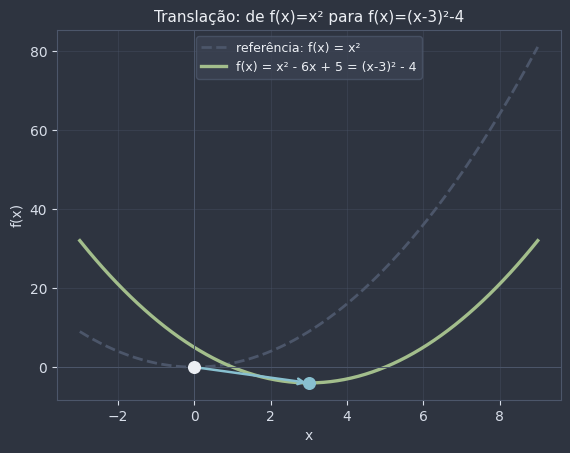

In [10]:
xs_translacao = np.linspace(-3, 9, 200)

fig, ax = plt.subplots(figsize=(6.5, 4.8))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(
    xs_translacao, funcao_quadratica(xs_translacao, 1, 0, 0), color=NORD_LINHA,
    linewidth=2, linestyle="--", label="referência: f(x) = x²",
)
ax.plot(
    xs_translacao, funcao_quadratica(xs_translacao, a_exemplo, b_exemplo, c_exemplo),
    color=COR_DESTAQUE, linewidth=2.4, label="f(x) = x² - 6x + 5 = (x-3)² - 4",
)
ax.annotate(
    "", xy=(float(h_exemplo), float(k_exemplo)), xytext=(0, 0),
    arrowprops=dict(arrowstyle="->", color=COR_PONTO, linewidth=1.8),
)
ax.scatter([0], [0], s=70, color=NORD_TEXTO, zorder=3)
ax.scatter([float(h_exemplo)], [float(k_exemplo)], s=70, color=COR_PONTO, zorder=3)
ax.axhline(0, color=NORD_LINHA, linewidth=0.7)
ax.axvline(0, color=NORD_LINHA, linewidth=0.7)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=9)
ax.set_xlabel("x", color=NORD_TEXTO_SEC)
ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
ax.set_title("Translação: de f(x)=x² para f(x)=(x-3)²-4", color=NORD_TEXTO, fontsize=11)
plt.show()

🕹️ **Widget interativo:** sliders para h e k (a fica fixo em 1), mostrando a parábola se deslocando em tempo real.

In [11]:
def explorar_translacao(h: float, k: float) -> None:
    xs = np.linspace(-8, 8, 200)
    ys_ref = funcao_quadratica(xs, 1, 0, 0)
    ys_deslocada = 1 * (xs - h) ** 2 + k

    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(xs, ys_ref, color=NORD_LINHA, linewidth=2, linestyle="--", label="referência: f(x) = x²")
    ax.plot(xs, ys_deslocada, color=COR_DESTAQUE, linewidth=2.4, label=f"f(x) = (x-{h:g})² + {k:g}")
    ax.scatter([h], [k], s=80, color=COR_PONTO, zorder=3)
    ax.axhline(0, color=NORD_LINHA, linewidth=0.7)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.7)
    ax.set_ylim(-10, 20)
    ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=9)
    ax.set_xlabel("x", color=NORD_TEXTO_SEC)
    ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
    ax.set_title("Forma canônica: translações de f(x) = x²", color=NORD_TEXTO, fontsize=11)
    plt.show()


widgets.interact(
    explorar_translacao,
    h=widgets.FloatSlider(value=3.0, min=-5, max=5, step=0.5, description="h:"),
    k=widgets.FloatSlider(value=-4.0, min=-5, max=5, step=0.5, description="k:"),
)

interactive(children=(FloatSlider(value=3.0, description='h:', max=5.0, min=-5.0, step=0.5), FloatSlider(value…

<function __main__.explorar_translacao(h: float, k: float) -> None>

**Perguntas de checagem:**
1. Ao aumentar k, para que lado a parábola se desloca?
2. Se h > 0, a parábola se desloca para a esquerda ou para a direita em relação a f(x) = ax²?

## Vértice da parábola

📌 O **vértice** é o ponto (xᵥ, yᵥ) onde a parábola muda de sentido (de crescente para decrescente, ou vice-versa). Duas formas equivalentes de calculá-lo:

$$x_v = -\frac{b}{2a}, \qquad y_v = -\frac{\Delta}{4a}$$

ou, diretamente pela forma canônica, xᵥ = h e yᵥ = k.

In [12]:
def explorar_vertice(a: float, b: float, c: float) -> None:
    if a == 0:
        print("a = 0 -> não é função quadrática")
        return

    vertice_x = -b / (2 * a)
    delta = b**2 - 4 * a * c
    vertice_y = -delta / (4 * a)

    xs = np.linspace(vertice_x - 6, vertice_x + 6, 300)
    ys = funcao_quadratica(xs, a, b, c)

    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(xs, ys, color=COR_DESTAQUE, linewidth=2.2)
    ax.axhline(vertice_y, color=NORD_LINHA, linewidth=0.8, linestyle=":")
    ax.axvline(vertice_x, color=NORD_LINHA, linewidth=0.8, linestyle=":")
    ax.scatter([vertice_x], [vertice_y], s=110, color=COR_PONTO, zorder=3, label="vértice")
    ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=9)
    ax.set_xlabel("x", color=NORD_TEXTO_SEC)
    ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
    ax.set_title(f"f(x) = {a:g}x² + {b:g}x + {c:g}", color=NORD_TEXTO, fontsize=11)
    plt.show()

    print(f"vértice: xv = -b/2a = {vertice_x:.2f}, yv = -Δ/4a = {vertice_y:.2f}")


widgets.interact(
    explorar_vertice,
    a=widgets.FloatSlider(value=1.0, min=-3, max=3, step=0.5, description="a:"),
    b=widgets.FloatSlider(value=-4.0, min=-10, max=10, step=1, description="b:"),
    c=widgets.FloatSlider(value=1.0, min=-10, max=10, step=1, description="c:"),
)

interactive(children=(FloatSlider(value=1.0, description='a:', max=3.0, min=-3.0, step=0.5), FloatSlider(value…

<function __main__.explorar_vertice(a: float, b: float, c: float) -> None>

**Perguntas de checagem:**
1. Por que o vértice é também chamado de ponto de máximo ou mínimo da função?
2. Se b = 0, onde fica xᵥ? Isso é coerente com as parábolas f(x) = ax² vistas no início do notebook?

## Eixo de simetria

💡 A reta vertical x = xᵥ é o **eixo de simetria** da parábola: para todo ponto do gráfico, existe um ponto espelhado do outro lado do eixo, à mesma altura.

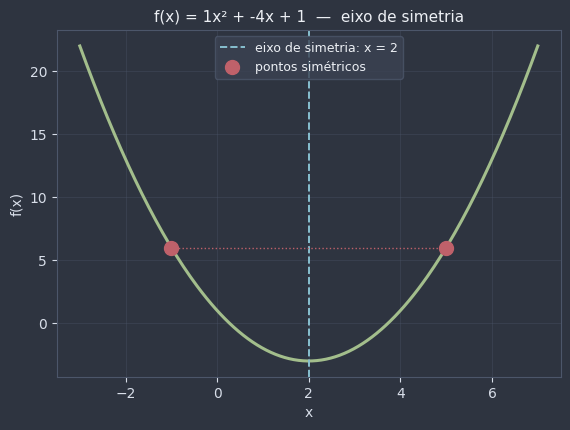

In [13]:
a_sim, b_sim, c_sim = 1, -4, 1
vertice_x_sim = -b_sim / (2 * a_sim)

xs_sim = np.linspace(vertice_x_sim - 5, vertice_x_sim + 5, 200)
ys_sim = funcao_quadratica(xs_sim, a_sim, b_sim, c_sim)

x_par1 = vertice_x_sim - 3
x_par2 = vertice_x_sim + 3
y_par = funcao_quadratica(x_par1, a_sim, b_sim, c_sim)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(xs_sim, ys_sim, color=COR_DESTAQUE, linewidth=2.2)
ax.axvline(vertice_x_sim, color=COR_PONTO, linewidth=1.4, linestyle="--", label=f"eixo de simetria: x = {vertice_x_sim:g}")
ax.scatter([x_par1, x_par2], [y_par, y_par], s=100, color=COR_ALERTA, zorder=3, label="pontos simétricos")
ax.plot([x_par1, x_par2], [y_par, y_par], color=COR_ALERTA, linewidth=1, linestyle=":")
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=9)
ax.set_xlabel("x", color=NORD_TEXTO_SEC)
ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
ax.set_title(f"f(x) = {a_sim:g}x² + {b_sim:g}x + {c_sim:g}  —  eixo de simetria", color=NORD_TEXTO, fontsize=11)
plt.show()

**Pergunta de checagem:** Se f(1) = f(5) para uma função quadrática, o que dá para concluir sobre o eixo de simetria dessa função?

## Máximos e mínimos

📌 Combinando concavidade + vértice:

- **a > 0** → yᵥ é o valor **mínimo** global da função
- **a < 0** → yᵥ é o valor **máximo** global da função

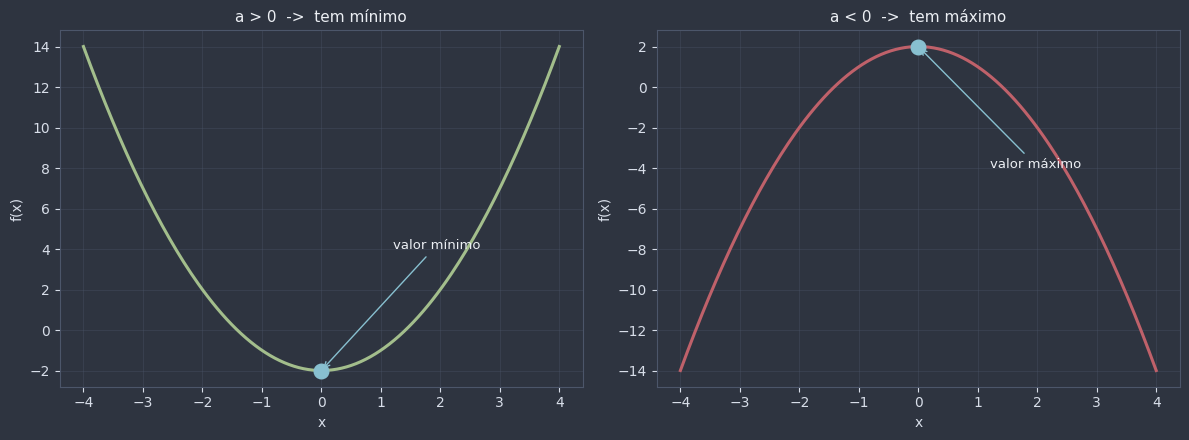

In [14]:
fig, (ax_min, ax_max) = plt.subplots(1, 2, figsize=(12, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)

xs_extremos = np.linspace(-4, 4, 200)

estilizar_eixo(ax_min)
ys_min = funcao_quadratica(xs_extremos, 1, 0, -2)
ax_min.plot(xs_extremos, ys_min, color=COR_DESTAQUE, linewidth=2.2)
ax_min.scatter([0], [-2], s=110, color=COR_PONTO, zorder=3)
ax_min.annotate(
    "valor mínimo", xy=(0, -2), xytext=(1.2, 4),
    color=NORD_TEXTO, fontsize=9.5,
    arrowprops=dict(arrowstyle="->", color=COR_PONTO),
)
ax_min.set_title("a > 0  ->  tem mínimo", color=NORD_TEXTO, fontsize=11)
ax_min.set_xlabel("x", color=NORD_TEXTO_SEC)
ax_min.set_ylabel("f(x)", color=NORD_TEXTO_SEC)

estilizar_eixo(ax_max)
ys_max = funcao_quadratica(xs_extremos, -1, 0, 2)
ax_max.plot(xs_extremos, ys_max, color=COR_ALERTA, linewidth=2.2)
ax_max.scatter([0], [2], s=110, color=COR_PONTO, zorder=3)
ax_max.annotate(
    "valor máximo", xy=(0, 2), xytext=(1.2, -4),
    color=NORD_TEXTO, fontsize=9.5,
    arrowprops=dict(arrowstyle="->", color=COR_PONTO),
)
ax_max.set_title("a < 0  ->  tem máximo", color=NORD_TEXTO, fontsize=11)
ax_max.set_xlabel("x", color=NORD_TEXTO_SEC)
ax_max.set_ylabel("f(x)", color=NORD_TEXTO_SEC)

plt.tight_layout()
plt.show()

**Pergunta de checagem:** Uma função quadrática pode ter máximo E mínimo global ao mesmo tempo? Por quê? (pense na concavidade)

## Imagem da função

📌 O conjunto imagem Im(f) é determinado pelo vértice e pela concavidade:

- **a > 0**: Im(f) = [yᵥ, +∞)
- **a < 0**: Im(f) = (-∞, yᵥ]

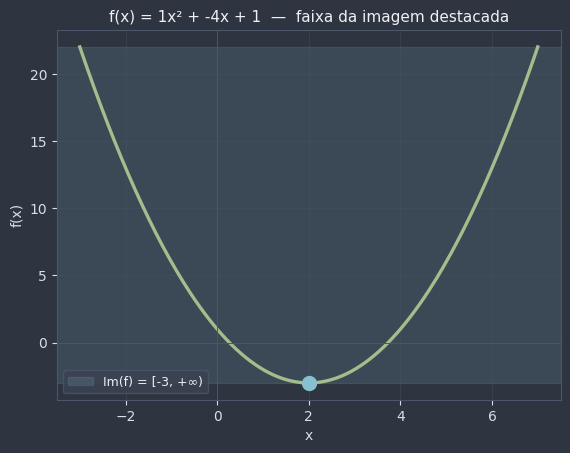

In [15]:
a_img, b_img, c_img = 1, -4, 1
vertice_x_img = -b_img / (2 * a_img)
delta_img = b_img**2 - 4 * a_img * c_img
vertice_y_img = -delta_img / (4 * a_img)

xs_img = np.linspace(vertice_x_img - 5, vertice_x_img + 5, 200)
ys_img = funcao_quadratica(xs_img, a_img, b_img, c_img)

fig, ax = plt.subplots(figsize=(6.5, 4.8))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.axhspan(vertice_y_img, ys_img.max(), color=COR_PONTO, alpha=0.15, label=f"Im(f) = [{vertice_y_img:g}, +∞)")
ax.plot(xs_img, ys_img, color=COR_DESTAQUE, linewidth=2.4)
ax.scatter([vertice_x_img], [vertice_y_img], s=100, color=COR_PONTO, zorder=3)
ax.axhline(0, color=NORD_LINHA, linewidth=0.7)
ax.axvline(0, color=NORD_LINHA, linewidth=0.7)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=9)
ax.set_xlabel("x", color=NORD_TEXTO_SEC)
ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
ax.set_title(f"f(x) = {a_img:g}x² + {b_img:g}x + {c_img:g}  —  faixa da imagem destacada", color=NORD_TEXTO, fontsize=11)
plt.show()

**Pergunta de checagem:** Qual é a imagem de f(x) = -2(x-3)² + 5?

## Aplicações práticas: otimização e MUV

⚠️ **Erro comum:** ao resolver um problema de otimização, encontrar o vértice matematicamente e esquecer de checar se ele está dentro do **domínio físico** do problema (por exemplo, uma dimensão negativa não faz sentido para um terreno).

### Voltando à cerca de 40 metros

Vamos resolver o problema do gancho por completo. Seja **x** a largura do retângulo (o lado perpendicular ao muro, que aparece duas vezes na cerca) e **y** o comprimento (o lado paralelo ao muro, cercado uma única vez):

1. **Restrição de cerca:** 2x + y = 40 → y = 40 - 2x
2. **Área em função de x:** A(x) = x·y = x(40 - 2x) = -2x² + 40x
3. A(x) é uma função quadrática com a = -2 < 0 → **tem máximo**
4. O vértice dá a resposta: xᵥ = -b/2a

largura ótima: x = 10 m
comprimento ótimo: y = 20 m
área máxima: A = 200 m²


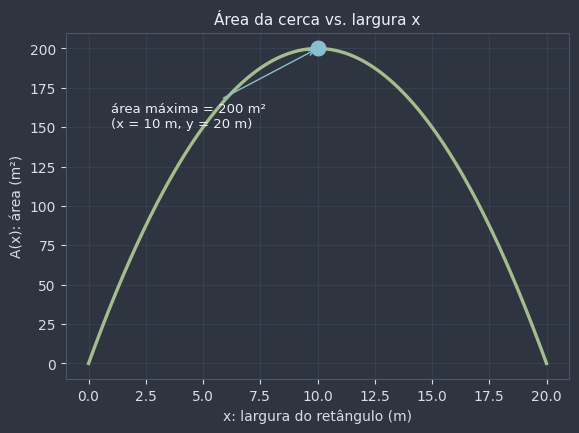

In [16]:
a_cerca, b_cerca, c_cerca = -2, 40, 0
x_otimo = -b_cerca / (2 * a_cerca)
area_maxima = funcao_quadratica(x_otimo, a_cerca, b_cerca, c_cerca)
y_otimo = 40 - 2 * x_otimo

print(f"largura ótima: x = {x_otimo:g} m")
print(f"comprimento ótimo: y = {y_otimo:g} m")
print(f"área máxima: A = {area_maxima:g} m²")

xs_cerca = np.linspace(0, 20, 200)
ys_cerca = funcao_quadratica(xs_cerca, a_cerca, b_cerca, c_cerca)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(xs_cerca, ys_cerca, color=COR_DESTAQUE, linewidth=2.4)
ax.scatter([x_otimo], [area_maxima], s=110, color=COR_PONTO, zorder=3)
ax.annotate(
    f"área máxima = {area_maxima:g} m²\n(x = {x_otimo:g} m, y = {y_otimo:g} m)",
    xy=(x_otimo, area_maxima), xytext=(1, 150),
    color=NORD_TEXTO, fontsize=9.5,
    arrowprops=dict(arrowstyle="->", color=COR_PONTO),
)
ax.set_xlabel("x: largura do retângulo (m)", color=NORD_TEXTO_SEC)
ax.set_ylabel("A(x): área (m²)", color=NORD_TEXTO_SEC)
ax.set_title("Área da cerca vs. largura x", color=NORD_TEXTO, fontsize=11)
plt.show()

🕹️ **Widget interativo:** slider para o comprimento total de cerca disponível — observe como a largura ótima e a área máxima mudam.

In [17]:
def explorar_cerca(comprimento_cerca: float) -> None:
    a_c, b_c = -2, comprimento_cerca
    x_ot = -b_c / (2 * a_c)
    area_max = funcao_quadratica(x_ot, a_c, b_c, 0)
    y_ot = comprimento_cerca - 2 * x_ot

    xs = np.linspace(0, comprimento_cerca / 2, 200)
    ys = funcao_quadratica(xs, a_c, b_c, 0)

    fig, ax = plt.subplots(figsize=(6.5, 4.3))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(xs, ys, color=COR_DESTAQUE, linewidth=2.2)
    ax.scatter([x_ot], [area_max], s=100, color=COR_PONTO, zorder=3)
    ax.set_xlabel("x: largura (m)", color=NORD_TEXTO_SEC)
    ax.set_ylabel("A(x): área (m²)", color=NORD_TEXTO_SEC)
    ax.set_title(f"cerca de {comprimento_cerca:g} m", color=NORD_TEXTO, fontsize=11)
    plt.show()

    print(f"largura ótima: x = {x_ot:g} m  |  comprimento ótimo: y = {y_ot:g} m  |  área máxima: {area_max:g} m²")


widgets.interact(
    explorar_cerca,
    comprimento_cerca=widgets.FloatSlider(value=40.0, min=20, max=100, step=5, description="cerca (m):"),
)

interactive(children=(FloatSlider(value=40.0, description='cerca (m):', min=20.0, step=5.0), Output()), _dom_c…

<function __main__.explorar_cerca(comprimento_cerca: float) -> None>

### MUV: altura de um projétil

A altura h de um projétil lançado verticalmente, em função do tempo t, segue a lei do **Movimento Uniformemente Variado**:

$$h(t) = h_0 + v_0 t - \frac{g}{2}t^2$$

onde h₀ é a altura inicial, v₀ é a velocidade inicial e g é a aceleração da gravidade (≈ 9,8 m/s²). Como o coeficiente de t² é -g/2 < 0, essa é sempre uma parábola com concavidade para baixo — **tem máximo**, que é a altura máxima atingida.

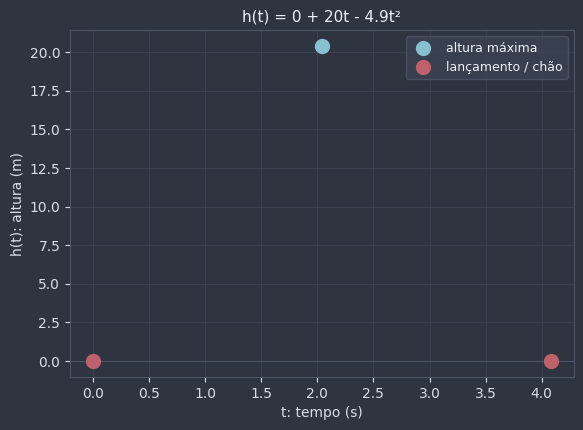

instante de altura máxima: t = 2.04 s
altura máxima: h = 20.41 m
o projétil toca o chão em: t = -0.00 s


In [19]:
h0, v0, g = 0.0, 20.0, 9.8
a_muv, b_muv, c_muv = -g / 2, v0, h0

t_pico = -b_muv / (2 * a_muv)
altura_maxima = funcao_quadratica(t_pico, a_muv, b_muv, c_muv)

delta_muv = b_muv**2 - 4 * a_muv * c_muv
t_zero_1 = (-b_muv - np.sqrt(delta_muv)) / (2 * a_muv)
t_zero_2 = (-b_muv + np.sqrt(delta_muv)) / (2 * a_muv)

ts = np.linspace(0, t_zero_2, 200)
hs = funcao_quadratica(ts, a_muv, b_muv, c_muv)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(ts, hs, color=COR_DESTAQUE, linewidth=2.4)
ax.scatter([t_pico], [altura_maxima], s=100, color=COR_PONTO, zorder=3, label="altura máxima")
ax.scatter([t_zero_1, t_zero_2], [0, 0], s=100, color=COR_ALERTA, zorder=3, label="lançamento / chão")
ax.axhline(0, color=NORD_LINHA, linewidth=0.7)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=9)
ax.set_xlabel("t: tempo (s)", color=NORD_TEXTO_SEC)
ax.set_ylabel("h(t): altura (m)", color=NORD_TEXTO_SEC)
ax.set_title(f"h(t) = {h0:g} + {v0:g}t - {g/2:g}t²", color=NORD_TEXTO, fontsize=11)
plt.show()

print(f"instante de altura máxima: t = {t_pico:.2f} s")
print(f"altura máxima: h = {altura_maxima:.2f} m")
print(f"o projétil toca o chão em: t = {t_zero_2:.2f} s")

**Pergunta de checagem:** Em um problema de otimização, por que às vezes o vértice matemático não é a resposta física válida?

## Resumo — cheat sheet

| Conceito | Fórmula / condição |
|---|---|
| Forma geral | f(x) = ax² + bx + c, com a ≠ 0 |
| Forma fatorada | f(x) = a(x - x₁)(x - x₂), quando Δ ≥ 0 |
| Forma canônica | f(x) = a(x - h)² + k, com h = -b/2a, k = f(h) |
| Discriminante | Δ = b² - 4ac |
| Bhaskara | x = (-b ± √Δ) / 2a |
| Número de raízes reais | Δ>0: duas · Δ=0: uma (dupla) · Δ<0: nenhuma |
| Vértice | xᵥ = -b/2a, yᵥ = -Δ/4a |
| Concavidade | a>0: para cima (tem mínimo) · a<0: para baixo (tem máximo) |
| Eixo de simetria | x = xᵥ |
| Imagem | [yᵥ, +∞) se a>0 · (-∞, yᵥ] se a<0 |

## Exercícios

**Básico**
1. Dada f(x) = x² - 5x + 6, calcule Δ, os zeros e as coordenadas do vértice.
2. Classifique a concavidade e diga se f(x) = -3x² + x - 1 tem máximo ou mínimo.

**Intermediário**
3. Escreva f(x) = 2x² - 8x + 3 na forma canônica e identifique a translação em relação a f(x) = 2x².
4. Determine a imagem de f(x) = -x² + 4x - 1.

**Desafio**
5. Um terreno retangular deve ter perímetro de 60 m. Expresse a área como função de um dos lados e encontre a área máxima possível.
6. (Interpretação gráfica) Dado o gráfico de uma parábola com vértice em (2, -3) passando por (0, 5), determine a lei da função.

Gabarito completo com resolução passo a passo em [`0108b_funcao_quadratica_grafico_e_propriedades_gabarito.ipynb`](0108b_funcao_quadratica_grafico_e_propriedades_gabarito.ipynb) — tente resolver sozinho antes de olhar.

### Básico

In [ ]:
# Exercício Básico 1: dada f(x) = x² - 5x + 6, calcule delta, os dois zeros
# (zero_menor <= zero_maior) e as coordenadas do vértice (vertice_x, vertice_y).
a_ex1, b_ex1, c_ex1 = 1, -5, 6

delta_ex1 = ...
zero_menor_ex1 = ...
zero_maior_ex1 = ...
vertice_x_ex1 = ...
vertice_y_ex1 = ...

print(delta_ex1, zero_menor_ex1, zero_maior_ex1, vertice_x_ex1, vertice_y_ex1)

In [ ]:
# Verificação
assert delta_ex1 == 1, "Tente de novo, revise o passo 1: Δ = b² - 4ac = (-5)² - 4(1)(6)."
assert (zero_menor_ex1, zero_maior_ex1) == (2, 3), (
    "Tente de novo, revise o passo 2: use Bhaskara com Δ = 1 (seção 4 - Zeros)."
)
assert vertice_x_ex1 == sp.Rational(5, 2), (
    "Tente de novo, revise o passo 3: xv = -b/2a (seção 6 - Vértice)."
)
assert vertice_y_ex1 == sp.Rational(-1, 4), (
    "Tente de novo, revise o passo 3: yv = -Δ/4a (seção 6 - Vértice)."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: classifique a concavidade de f(x) = -3x² + x - 1
# ("para cima" ou "para baixo") e diga se ela tem máximo ou mínimo
# ("maximo" ou "minimo").
a_ex2 = -3

concavidade_ex2 = ...
extremo_ex2 = ...

print(concavidade_ex2, extremo_ex2)

In [ ]:
# Verificação
assert concavidade_ex2 == "para baixo", (
    "Tente de novo, revise o passo 1: a = -3 < 0 (seção 3 - Concavidade)."
)
assert extremo_ex2 == "maximo", (
    "Tente de novo, revise o passo 2: a < 0 -> tem máximo (seção 8 - Máximos e mínimos)."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: escreva f(x) = 2x² - 8x + 3 na forma canônica
# a(x-h)² + k (calcule h_ex3 e k_ex3) e diga a translação em relação a
# f(x) = 2x² como uma tupla (deslocamento_horizontal, deslocamento_vertical).
a_ex3, b_ex3, c_ex3 = 2, -8, 3

h_ex3 = ...
k_ex3 = ...
translacao_ex3 = ...  # tupla (h_ex3, k_ex3)

print(h_ex3, k_ex3, translacao_ex3)

In [ ]:
# Verificação
assert h_ex3 == 2, "Tente de novo, revise o passo 1: h = -b/2a (seção 5 - Forma canônica)."
assert k_ex3 == -5, "Tente de novo, revise o passo 2: k = f(h) (seção 5 - Forma canônica)."
assert translacao_ex3 == (2, -5), (
    "Tente de novo, revise o passo 3: a translação é exatamente (h, k)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 4: determine a imagem de f(x) = -x² + 4x - 1
# como uma tupla (limite_ex4, "maior_igual" ou "menor_igual"), onde
# limite_ex4 é o valor yv que limita a imagem.
a_ex4, b_ex4, c_ex4 = -1, 4, -1

limite_ex4 = ...
tipo_imagem_ex4 = ...  # "maior_igual" -> Im(f) = [limite, +inf); "menor_igual" -> (-inf, limite]

print(limite_ex4, tipo_imagem_ex4)

In [ ]:
# Verificação
assert limite_ex4 == 3, "Tente de novo, revise o passo 1: yv = -Δ/4a (seção 6 - Vértice)."
assert tipo_imagem_ex4 == "menor_igual", (
    "Tente de novo, revise o passo 2: a = -1 < 0 -> Im(f) = (-∞, yv] (seção 9 - Imagem)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 5: um terreno retangular tem perímetro de 60 m. Seja x
# um dos lados; expresse a área A(x) com os coeficientes a_ex5, b_ex5,
# c_ex5 (A(x) = a_ex5*x**2 + b_ex5*x + c_ex5) e encontre a área máxima
# possível (area_maxima_ex5).
a_ex5 = ...
b_ex5 = ...
c_ex5 = ...
area_maxima_ex5 = ...

print(a_ex5, b_ex5, c_ex5, area_maxima_ex5)

In [ ]:
# Verificação
assert (a_ex5, b_ex5, c_ex5) == (-1, 30, 0), (
    "Tente de novo, revise o passo 1: perímetro 2x+2y=60 -> y=30-x; "
    "A(x) = x*(30-x) = -x² + 30x (seção 10 - Aplicações)."
)
assert area_maxima_ex5 == 225, (
    "Tente de novo, revise o passo 2: área máxima = yv = -Δ/4a com a,b,c acima."
)
print("Certo!")

In [ ]:
# Exercício Desafio 6: uma parábola tem vértice em (2, -3) e passa por
# (0, 5). Encontre os coeficientes a_ex6, b_ex6, c_ex6 da forma geral
# f(x) = a_ex6*x**2 + b_ex6*x + c_ex6.
a_sym_ex6, b_sym_ex6, c_sym_ex6 = sp.symbols("a b c")

# dica: use a forma canônica f(x) = a(x-2)² - 3 e o ponto (0, 5) para achar a;
# depois expanda para obter b e c.
a_ex6 = ...
b_ex6 = ...
c_ex6 = ...

print(a_ex6, b_ex6, c_ex6)

In [ ]:
# Verificação
assert a_ex6 == 2, (
    "Tente de novo, revise o passo 1: f(0) = a(0-2)² - 3 = 4a - 3 = 5 -> a = 2 "
    "(seção 5 - Forma canônica)."
)
assert (b_ex6, c_ex6) == (-8, 5), (
    "Tente de novo, revise o passo 2: expanda 2(x-2)² - 3 = 2x² - 8x + 5."
)
print("Certo!")

## Conexões

**Isso depende de:**
- [`0107a_funcoes_primeiro_grau.ipynb`](0107a_funcoes_primeiro_grau.ipynb) (função afim, coeficiente angular/linear, zero de uma função)
- [`0105a_funcoes.ipynb`](0105a_funcoes.ipynb) (conceito de função, domínio/contradomínio/imagem, gráfico no plano cartesiano)
- [00_fundamentos_e_python/](../00_fundamentos_e_python/) (Python básico) e resolução de equações do 1º grau

**Isso será usado em:**
- [`0109a_funcao_quadratica_sinal_inequacoes_e_raizes.ipynb`](0109a_funcao_quadratica_sinal_inequacoes_e_raizes.ipynb) (sinal, inequações do 2º grau, relações de Girard e o teorema da comparação com as raízes)
- [`04_geometria_plana/`](../04_geometria_plana/) e [`07_geometria_analitica_plana_e_espacial/`](../07_geometria_analitica_plana_e_espacial/) (cônicas — a parábola revisitada com foco e diretriz)
- [`11_limite_integral_e_derivada/`](../11_limite_integral_e_derivada/) (otimização com derivada — o vértice revisitado como ponto crítico)